In [20]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict 
#Key - value pair madhe data type batane kemliye - TypeDict

In [21]:
#Define state
class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    category:str
    
    

In [22]:
def calculate_bmi(state:BMIState)->BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    
    bmi = weight/(height**2)
    
    state['bmi'] = round(bmi,2)
    return state

In [ ]:
#label_bmi function

def label_bmi(state:BMIState) -> BMIState:
    bmi = state['bmi']
    
    if bmi<18.5:
        state["category"] ="Underweight"
    elif 18.5 <= 25:
        state["category"] = "Normal"
    elif 25 <= 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"
    return state



In [25]:
#define your graph
graph = StateGraph(BMIState)


#add nodes to graph

graph.add_node('calculate_bmi',calculate_bmi)

graph.add_node("label_bmi",label_bmi)


#add edges to graph

graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi',"label_bmi")
graph.add_edge("label_bmi",END)




#Compile the graph

workflow = graph.compile()

#excute the graph

In [28]:
#excute the graph:-
intial_state = {'weight_kg':80,'height_m':1.73}
final_state = workflow.invoke(intial_state)
print(final_state)


TypeError: 'dict' object is not callable

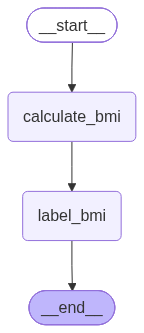

In [26]:
#To see graph visually
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
